<a href="https://colab.research.google.com/github/algaebrown/RBPNet/blob/main/rbpnet_colab_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U "huggingface_hub[cli]"
!pip install seqpro
!pip install pytorch-lightning
!pip install tqdm
!hf download yeolab/eCLIP \
    --repo-type dataset \
    --include "RBFOX2_HepG2_ENCSR987FTF/**" \
    --local-dir eCLIP
!git clone https://github.com/algaebrown/RBPNet.git

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 1463.78it/s]
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B                         ✓ Downloaded
  path: /content/eCLIP
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
fatal: destination path 'RBPNet' already exists and is not an empty directory.


In [2]:
from datasets import load_dataset
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import seqpro as sp

import sys
sys.path.append("RBPNet")
from RBPNet import RBPNet
### Module ###
from module import Module
from losses import rbpnet_loss
from metrics import rbpnet_metrics, dlog_odds_from_data, pearson_corr

# Set-up callbacks
from genericpath import exists
# Logger
import os
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.lr_monitor import LearningRateMonitor
from pytorch_lightning import Trainer

# plot training curve
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from tqdm import tqdm



In [3]:
ds = load_dataset(
    "yeolab/eCLIP",
    name="RBFOX2_HepG2_ENCSR987FTF",
)

In [4]:


class ECLIPDataset(Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        seq = np.char.upper(ex["seq"])
        seq = sp.ohe(seq, sp.alphabets.DNA).swapaxes(0, 1)

        control = np.asarray(ex["control"], dtype=np.float32)
        signal = np.asarray(ex["signal"], dtype=np.float32)

        return {
            "seq": torch.from_numpy(seq).float(),
            "control": torch.from_numpy(control).float(),
            "signal": torch.from_numpy(signal).float(),
            "gc_fraction": torch.tensor(ex["gc_fraction"], dtype=torch.float32),
            "n_IN": torch.tensor(ex["n_IN"], dtype=torch.float32),
            "n_IP": torch.tensor(ex["n_IP"], dtype=torch.float32),
        }



In [5]:
train_dataset = ECLIPDataset(ds["train"])

train_dl = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

valid_dataset = ECLIPDataset(ds["validation"])
valid_dl = DataLoader(
    valid_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

test_dataset = ECLIPDataset(ds["test"])
test_dl = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [6]:
for dset in ['test', 'train', 'validation']:
  chroms = ds[dset].unique("chrom")
  print(dset, ':', chroms)

test : ['chr2', 'chr9', 'chr16']
train : ['chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
validation : ['chr1', 'chr8', 'chr15']


In [7]:
# architecture

mask = 100
arch = RBPNet(mask = mask)

In [8]:

# LightningModule
module = Module(
    arch=arch,
    input_variables=["seq"],
    output_variables=["eCLIP_profile", "signal_profile", "control_profile", "mixing_coefficient",
                    "d_log_odds"],
    target_variables=["signal", "control", "gc_fraction", "n_IN", "n_IP"],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)


In [9]:

log_dir = './log'
if not exists(log_dir):
    os.makedirs(log_dir)

logger = CSVLogger(save_dir=log_dir, name="", version="")


callbacks = []
model_checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join(
        logger.save_dir,
        logger.name,
        logger.version,
        "checkpoints"
    ),
    save_top_k=5,
    monitor="val_loss_epoch",
)
callbacks.append(model_checkpoint_callback)
early_stopping_callback = EarlyStopping(
    monitor="val_loss_epoch",
    patience=10,
    mode="min",
    verbose=True,
    #check_on_train_epoch_end=False ###https://github.com/Lightning-AI/pytorch-lightning/issues/9151
)
callbacks.append(early_stopping_callback)
callbacks.append(LearningRateMonitor())
callbacks



In [10]:
# Trainer

trainer = Trainer(
    max_epochs=20,
    logger=logger,
    devices="auto",
    accelerator="auto",
    callbacks=callbacks,
    num_sanity_val_steps=2
)

# Fit
trainer.fit(
    module,
    train_dataloaders=train_dl,
    val_dataloaders=valid_dl,
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory ./log/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/log/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ arch │ RBPNet │  899 K │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 899 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 899 K                                                                                                
Total estimated model params size (MB): 3.599                                                                      
Modules in train mode: 59                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

{'val_loss_epoch': tensor(1192.0344, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(652.8907, device='cuda:0'), 
'val_control_loss_epoch': tensor(420.3723, device='cuda:0'), 'val_binom_loss_epoch': tensor(58.9375, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.6001, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3567, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.4556, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.6244, device='cuda:0')}

{'val_loss_epoch': tensor(1202.6611, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(616.7397, device='cuda:0'), 
'val_control_loss_epoch': tensor(423.4623, device='cuda:0'), 'val_binom_loss_epoch': tensor(80.3188, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.6067, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3569, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.3834, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.5862, device='cuda:0')}

{'val_loss_epoch': tensor(1251.4186, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(687.0359, device='cuda:0'), 
'val_control_loss_epoch': tensor(396.8572, device='cuda:0'), 'val_binom_loss_epoch': tensor(84.6135, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.6217, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3628, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.3562, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.5242, device='cuda:0')}

{'val_loss_epoch': tensor(1391.9961, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(722.9323, device='cuda:0'), 
'val_control_loss_epoch': tensor(492.1920, device='cuda:0'), 'val_binom_loss_epoch': tensor(91.4176, 
device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.5502, device='cuda:0'), 
'val_control_profile_pearson_epoch': tensor(0.3629, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': 
tensor(0.4762, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.6445, device='cuda:0')}

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


/tmp/ipykernel_57571/3055548148.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


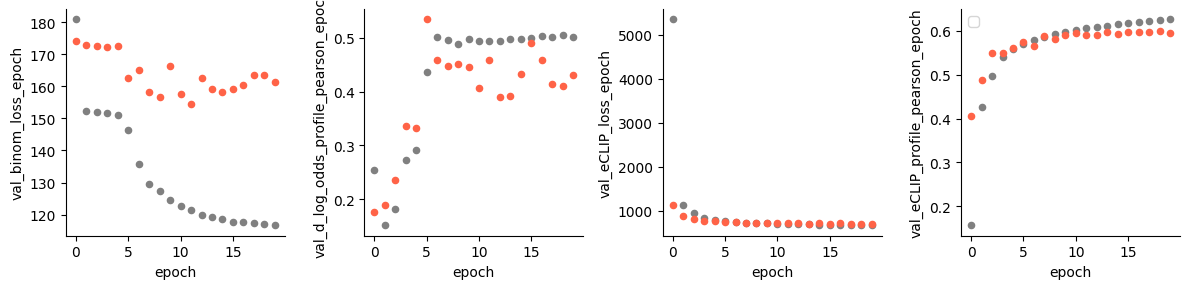

In [11]:

f, axes = plt.subplots(1,4,figsize = (12,3))
metric_df = pd.read_csv(Path(log_dir) / 'metrics.csv')
metric_df.plot.scatter(x = 'epoch', y = 'train_binom_loss_epoch',
                    ax = axes[0], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_binom_loss_epoch',
                    ax = axes[0], color = 'tomato')

metric_df.plot.scatter(x = 'epoch',
                    y = 'train_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'grey')
metric_df.plot.scatter(x = 'epoch',
                    y = 'val_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_loss_epoch',
                    ax = axes[2], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_loss_epoch',
                    ax = axes[2], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'tomato')
plt.tight_layout()
plt.legend()
sns.despine()

In [12]:
best_path = trainer.checkpoint_callback.best_model_path

module = Module.load_from_checkpoint(
    best_path,
    arch=RBPNet(mask=100),
    input_variables=["seq"],
    output_variables=[
        "eCLIP_profile",
        "signal_profile",
        "control_profile",
        "mixing_coefficient",
        "d_log_odds"
    ],
    target_variables=[
        "signal",
        "control",
        "gc_fraction",
        "n_IN",
        "n_IP"
    ],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)

In [13]:
module.eval()
device = next(module.parameters()).device

all_pred = []
all_pi = []
all_dlogodds = []
all_signal = []
all_gc = []
all_nIP = []
all_nIN = []
all_name = []
all_strand = []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Predicting"):

        x = batch["seq"].to(device)

        # forward once
        outputs = module.arch(x)

        all_pred.append(outputs[0].cpu())
        all_pi.append(outputs[3].cpu())
        all_dlogodds.append(outputs[4].cpu())

        all_signal.append(batch["signal"].cpu())
        all_gc.append(batch["gc_fraction"].cpu())
        all_nIP.append(batch["n_IP"].cpu())
        all_nIN.append(batch["n_IN"].cpu())

        if "name" in batch:
            all_name.extend(batch["name"])

        if "strand" in batch:
            all_strand.extend(batch["strand"])


y_pred = torch.cat(all_pred)
pis = torch.cat(all_pi).squeeze()
dlogodds = torch.cat([
    x if x.dim() == 1 else x.unsqueeze(-1)
    for x in all_dlogodds
])

y_clip = torch.cat(all_signal)
gc_fraction = torch.cat(all_gc)
n_IP = torch.cat(all_nIP)
n_IN = torch.cat(all_nIN)

Predicting:   0%|          | 0/73 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Predicting: 100%|██████████| 73/73 [00:54<00:00,  1.34it/s]


In [14]:

y_total = y_clip.sum(dim=1, keepdim=True)

# predicted profile
probs = torch.softmax(y_pred, dim=1)
expected_counts = probs * y_total

pearsons = pearson_corr(expected_counts, y_clip).cpu().numpy()

# compute d_log_odds from data
y_logodd, y_dlogodd = dlog_odds_from_data(
    {
        "n_IP": n_IP,
        "n_IN": n_IN,
        "gc_fraction": gc_fraction,
    }
)

# combine metrics for tests metrics
test_metrics = pd.DataFrame({
    'profile_pearsons': pearsons,
    'pi': pis.squeeze(),
    'dlogodds_pred': dlogodds,
    'dlogodds': y_dlogodd,
    'logodds': y_logodd,
    'n_IP': n_IP,
    'n_IN': n_IN,
    'gc_fraction': gc_fraction,
}
                        )
test_metrics['total'] = test_metrics['n_IP']+test_metrics['n_IN']



In [15]:

data_output = {}
for nread in [10,50,100,200]:
    # at low coverage region, the signal is noisy
    # the paper showed correlation > 50 reads
    pearson_means = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].mean()
    pearson_std = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].std()
    data_output[f'mean profile_pearson(total>{nread})']=pearson_means
    data_output[f'std profile_pearson(total>{nread})']=pearson_std

data_output['dlogodds pearson'], _=pearsonr(test_metrics['dlogodds'],test_metrics['dlogodds_pred'])

for nread in [10,50,100,200]:
    sub = test_metrics[test_metrics['total']>nread]
    r,p = pearsonr(sub['dlogodds'],sub['dlogodds_pred'])
    data_output[f'dlogodds pearson(total>{nread})']=r

    r,p = pearsonr(sub['pi'],sub['dlogodds_pred'])
    data_output[f'pi pearson(total>{nread})']=r

data_output

{'mean profile_pearson(total>10)': np.float32(0.65410864),
 'std profile_pearson(total>10)': 0.27329808473587036,
 'mean profile_pearson(total>50)': np.float32(0.6959589),
 'std profile_pearson(total>50)': 0.2978246808052063,
 'mean profile_pearson(total>100)': np.float32(0.6590437),
 'std profile_pearson(total>100)': 0.3436436057090759,
 'mean profile_pearson(total>200)': np.float32(0.58308303),
 'std profile_pearson(total>200)': 0.40419909358024597,
 'dlogodds pearson': np.float32(0.46318248),
 'dlogodds pearson(total>10)': np.float32(0.5014514),
 'pi pearson(total>10)': np.float32(0.8841603),
 'dlogodds pearson(total>50)': np.float32(0.5937723),
 'pi pearson(total>50)': np.float32(0.92105913),
 'dlogodds pearson(total>100)': np.float32(0.67751616),
 'pi pearson(total>100)': np.float32(0.9441091),
 'dlogodds pearson(total>200)': np.float32(0.72269666),
 'pi pearson(total>200)': np.float32(0.9620933)}

In [16]:
pd.Series(data_output).sort_index()

,0
dlogodds pearson,0.463182
dlogodds pearson(total>10),0.501451
dlogodds pearson(total>100),0.677516
dlogodds pearson(total>200),0.722697
dlogodds pearson(total>50),0.593772
mean profile_pearson(total>10),0.654109
mean profile_pearson(total>100),0.659044
mean profile_pearson(total>200),0.583083
mean profile_pearson(total>50),0.695959
pi pearson(total>10),0.884160


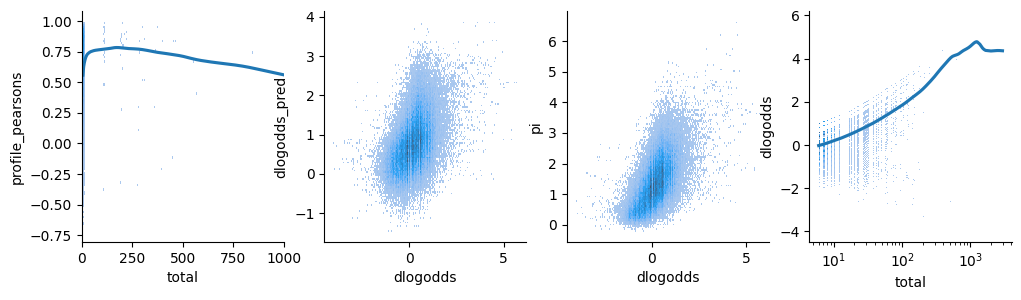

In [17]:
f, axes = plt.subplots(1,4, figsize = (12,3))
sns.histplot(data = test_metrics,x='total', y='profile_pearsons', ax = axes[0])
sns.regplot(data = test_metrics,x='total', y='profile_pearsons', scatter = False, ax = axes[0],lowess=True)
axes[0].set_xlim(0,1000)

sns.histplot(data = test_metrics, x='dlogodds', y='dlogodds_pred', ax = axes[1])

sns.histplot(data = test_metrics, x='dlogodds', y='pi', ax = axes[2])

sns.histplot(data =test_metrics, x='total', y='dlogodds', ax = axes[3])
sns.regplot(data =test_metrics, x='total', y='dlogodds', scatter = False, ax = axes[3],lowess=True)
axes[3].set_xscale('log')
sns.despine()

In [18]:
# download checkpoints
!zip -r log.zip log/
from google.colab import files
files.download("log.zip")

updating: log/ (stored 0%)
updating: log/metrics.csv (deflated 73%)
updating: log/checkpoints/ (stored 0%)
updating: log/checkpoints/epoch=2-step=4986.ckpt (deflated 16%)
updating: log/checkpoints/epoch=4-step=8310.ckpt (deflated 16%)
updating: log/checkpoints/epoch=15-step=26592.ckpt (deflated 15%)
updating: log/checkpoints/epoch=3-step=6648.ckpt (deflated 16%)
updating: log/checkpoints/epoch=5-step=9972.ckpt (deflated 16%)
updating: log/checkpoints/epoch=18-step=31578.ckpt (deflated 16%)
updating: log/checkpoints/epoch=13-step=23268.ckpt (deflated 15%)
updating: log/checkpoints/epoch=12-step=21606.ckpt (deflated 15%)
updating: log/checkpoints/epoch=19-step=33240.ckpt (deflated 16%)
updating: log/checkpoints/epoch=1-step=3324.ckpt (deflated 17%)
  adding: log/checkpoints/epoch=15-step=26592-v1.ckpt (deflated 15%)
  adding: log/checkpoints/epoch=19-step=33240-v1.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=18-step=31578-v1.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=10-s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# from huggingface_hub import create_repo

# create_repo(
#     "yeolab/RBPNet",
#     repo_type="model"
# )